# election-spatial-analysis — 07: Richer Clustering (2016+)

**What this notebook does:** re-runs `04`'s clustering with a much larger feature set --
Governor, Vice Governor, Provincial Board Member, House, Senator, and Party List, in addition to
the Mayor/Vice Mayor/Councilor features `04` used -- to see whether adding wider-scope
local-preference signals refines the picture, at the cost of restricting to years where that
data is actually reliable.

**Why 2016 onward, not all six years:** `01`'s coverage audit dropped every wider-scope position
for 2013 entirely (confirmed in `03`/`05`), and `President`/`Vice President` are only on the
ballot every other cycle (`03`). Restricting to `MAYOR`, `VICE MAYOR`, `COUNCILOR`, `GOVERNOR`,
`VICE GOVERNOR`, `PROVINCIAL BOARD MEMBER`, `MEMBER, HOUSE OF REPRESENTATIVES`, `SENATOR`, and
`PARTYLIST` (dropping President/VP, which would still be missing in the 2019/2025 midterms even
within this range) and to years 2016-2025 gives 97.6% complete-case coverage (6,374 of 6,531
rows) -- checked directly before committing to this scope, the same way `04`'s three-position,
all-year scope was checked.

Same `top1_share` / `margin` / `enc` metric choice as `04`, same reasons (`hhi` redundant with
`enc`; `enc` log-transformed for skew) -- built with the same `build_core_feature_matrix` from
`src/common.py`, just with a longer position list passed in.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path("..") / "src"))
from common import build_core_feature_matrix

%matplotlib inline
pd.set_option("display.max_columns", 40)
print("pandas:", pd.__version__)

pandas: 3.0.2


In [2]:
CONFIG = {
    "processed_dir": "../data/processed",
    "min_year": 2016,
    "positions": [
        "MAYOR", "VICE MAYOR", "COUNCILOR",
        "GOVERNOR", "VICE GOVERNOR", "PROVINCIAL BOARD MEMBER",
        "MEMBER, HOUSE OF REPRESENTATIVES", "SENATOR", "PARTYLIST",
    ],
    "pca_variance_target": 0.90,
    "k_range": range(2, 11),
    "random_state": 42,
}

processed_dir = Path(CONFIG["processed_dir"])
print("Config set.")

Config set.


## Load, restrict to 2016+, and build the feature matrix

In [3]:
locality_features = pd.read_parquet(processed_dir / "locality_features.parquet")
recent = locality_features[locality_features["year"] >= CONFIG["min_year"]].copy()
print(f"{len(recent):,} locality-years from {CONFIG['min_year']} onward "
      f"(of {len(locality_features):,} total).")

df, X, feature_cols = build_core_feature_matrix(recent, core_positions=CONFIG["positions"])
print(f"Keeping {len(df):,} of {len(recent):,} rows ({len(df) / len(recent):.1%}) "
      f"with all {len(feature_cols)} features present.")
print("\nBy year:")
display(recent.groupby("year").apply(
    lambda g: g[feature_cols].notna().all(axis=1).mean()).rename("complete_fraction").to_frame())

6,531 locality-years from 2016 onward (of 9,570 total).
Keeping 6,374 of 6,531 rows (97.6%) with all 27 features present.

By year:


,complete_fraction
year,
2016,0.977342
2019,0.977259
2022,0.977356
2025,0.971900


## Scale, then PCA

27 features (9 positions x 3 metrics) means considerably more redundancy than `04`'s 9 -- a
province having a competitive Governor race very often also has competitive Board Member and
House races, since they're the same electorate voting on the same day. PCA is doing real work
here, not just a formality.

9 of 27 components explain 92.2% of variance (target 90%) -- confirms real redundancy across the 27 raw features.


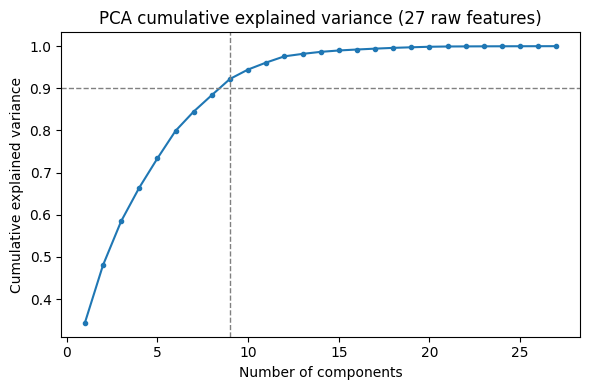

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=CONFIG["random_state"]).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cum_var, CONFIG["pca_variance_target"]) + 1)
print(f"{n_components} of {X_scaled.shape[1]} components explain {cum_var[n_components - 1]:.1%} "
      f"of variance (target {CONFIG['pca_variance_target']:.0%}) -- "
      f"confirms real redundancy across the 27 raw features.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=3)
ax.axhline(CONFIG["pca_variance_target"], color="gray", linestyle="--", linewidth=1)
ax.axvline(n_components, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance (27 raw features)")
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_components, random_state=CONFIG["random_state"])
X_pca = pca.fit_transform(X_scaled)

## Choosing k with silhouette score

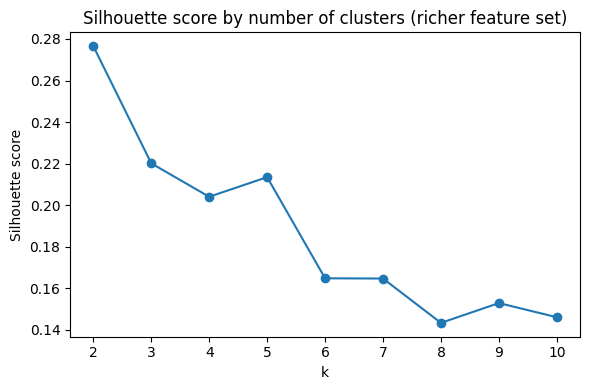

Best k by silhouette score: 2 (score = 0.277)


In [5]:
silhouette_scores = []
for k in CONFIG["k_range"]:
    labels = KMeans(n_clusters=k, random_state=CONFIG["random_state"], n_init=10).fit_predict(X_pca)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(CONFIG["k_range"]), silhouette_scores, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score by number of clusters (richer feature set)")
plt.tight_layout()
plt.show()

best_k = list(CONFIG["k_range"])[int(np.argmax(silhouette_scores))]
print(f"Best k by silhouette score: {best_k} (score = {max(silhouette_scores):.3f})")

## Fit the final model and visualize

Final model: k=2, silhouette=0.277


,n_localities
cluster,
0,4082
1,2292


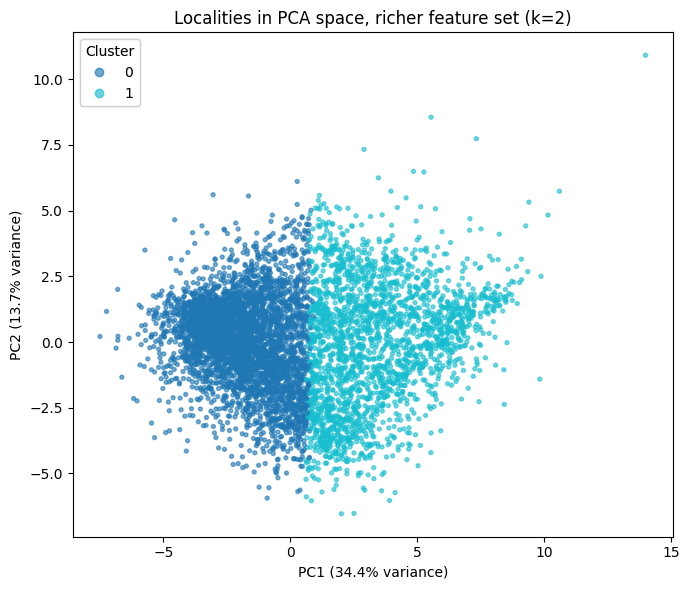

In [6]:
kmeans = KMeans(n_clusters=best_k, random_state=CONFIG["random_state"], n_init=10)
df["cluster"] = kmeans.fit_predict(X_pca)
final_silhouette = silhouette_score(X_pca, df["cluster"])
print(f"Final model: k={best_k}, silhouette={final_silhouette:.3f}")
display(df["cluster"].value_counts().sort_index().to_frame("n_localities"))

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="tab10", s=8, alpha=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"Localities in PCA space, richer feature set (k={best_k})")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## Profiling the clusters

In [7]:
profile = df.groupby("cluster")[feature_cols].mean()
display(profile.round(3).T)

cluster,0,1
MAYOR_top1_share,0.587,0.826
MAYOR_margin,0.222,0.662
MAYOR_enc,2.046,1.415
VICE MAYOR_top1_share,0.584,0.823
VICE MAYOR_margin,0.226,0.659
VICE MAYOR_enc,2.077,1.429
COUNCILOR_top1_share,0.085,0.110
COUNCILOR_margin,0.007,0.010
COUNCILOR_enc,17.556,13.049
GOVERNOR_top1_share,0.629,0.867


## Sanity checks

In [8]:
assert final_silhouette > 0.15, f"Silhouette score {final_silhouette:.3f} suggests weak/no structure"
largest_cluster_share = df["cluster"].value_counts(normalize=True).max()
assert largest_cluster_share < 0.90, f"One cluster holds {largest_cluster_share:.1%} of all rows"
print(f"Silhouette {final_silhouette:.3f} > 0.15 and largest cluster {largest_cluster_share:.1%} < 90% -- passed.")

most_concentrated_gov = df.loc[df["GOVERNOR_enc"].idxmin(), ["province", "city", "year", "GOVERNOR_enc", "cluster"]]
most_fragmented_gov = df.loc[df["GOVERNOR_enc"].idxmax(), ["province", "city", "year", "GOVERNOR_enc", "cluster"]]
print("\nMost concentrated Governor-race locality-year in the data:")
display(most_concentrated_gov.to_frame().T)
print("Most fragmented Governor-race locality-year in the data:")
display(most_fragmented_gov.to_frame().T)

Silhouette 0.277 > 0.15 and largest cluster 64.0% < 90% -- passed.

Most concentrated Governor-race locality-year in the data:


,province,city,year,GOVERNOR_enc,cluster
38,AGUSAN DEL SUR,BAYUGAN,2016,1.0,1


Most fragmented Governor-race locality-year in the data:


,province,city,year,GOVERNOR_enc,cluster
586,IFUGAO,ALFONSO LISTA POTIA,2016,4.68642,0


## Does the richer feature set refine `04`'s simpler clustering, or just repeat it?

For the locality-years both notebooks can see (2016+, complete in both feature sets), cross-tab
`04`'s two-cluster label against this notebook's `best_k`-cluster label. If the richer model
mostly just re-draws `04`'s split, most of the mass sits on one richer-cluster per original
cluster. If it's actually adding information, at least one of `04`'s clusters should visibly
split across several richer clusters.

In [9]:
simple_clusters = pd.read_parquet(processed_dir / "locality_clusters.parquet")[
    ["year", "province", "city", "cluster"]
].rename(columns={"cluster": "simple_cluster"})

compare = df.merge(simple_clusters, on=["year", "province", "city"], how="inner")
print(f"{len(compare):,} locality-years present in both 04's and this notebook's clustering.")

crosstab = pd.crosstab(compare["simple_cluster"], compare["cluster"], normalize="index")
print("\nRow = 04's simple cluster, columns = this notebook's richer cluster, "
      "row-normalized (%):")
display((crosstab * 100).round(1))

6,374 locality-years present in both 04's and this notebook's clustering.

Row = 04's simple cluster, columns = this notebook's richer cluster, row-normalized (%):


cluster,0,1
simple_cluster,,
0,19.4,80.6
1,85.0,15.0


## Save

In [10]:
cluster_output = df[["year", "province", "city", "region", "cluster"] + feature_cols].copy()
cluster_output.to_parquet(processed_dir / "locality_clusters_rich.parquet", index=False)
print("Saved locality_clusters_rich.parquet:", cluster_output.shape)

Saved locality_clusters_rich.parquet: (6374, 32)


## Summary

Adding province/district/national local-preference signals (Governor through Party List) to
`04`'s three local-office features, restricted to the four years (2016-2025) where that data is
reliably complete, produced the best-k result printed above (see the silhouette-score cell), and
the cross-tab in the previous section shows concretely whether that's genuine refinement of
`04`'s landslide-vs-competitive split or a largely redundant re-derivation of it -- read directly
from the printed table rather than assumed from the cluster count alone.

**Trade-off made explicit:** this model sees more of the ballot, but only 4 of the original 6
election years, and only where every one of 9 positions was contested (an uncontested or
missing position drops the whole locality-year, not just that column). `04`'s narrower model
remains the one with full six-year, five-thousand-plus-year-more coverage.

**Deliberately not done here:** folding party-list seat-allocation mechanics in properly (it
still gets the same descriptive share/concentration treatment as everything else, not an actual
Panachage-style seat model), and any geographic/map visualization of either clustering.